# Build LangGraph Design Patterns: Orchestration & Evaluation

In [6]:
# Required Libraries
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send

from IPython.display import Image, display
import os
from dotenv import load_dotenv
load_dotenv()

from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the language model - using gpt-4o-mini for cost-effective experimentation
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", api_key=os.getenv("GOOGLE_API_KEY"))

### Orchestrator - Worker Pattern

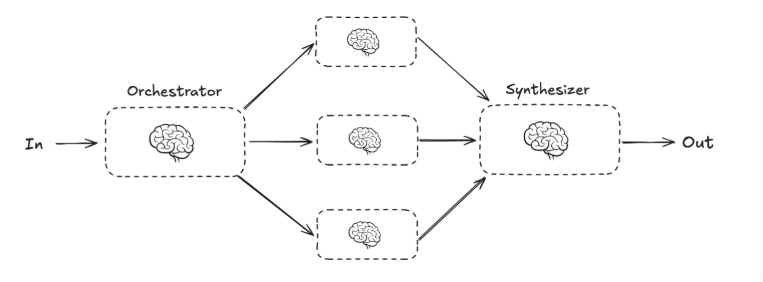

<b> Structured Output

The orchestrator must produce structured outputs because our worker nodes require specific, well-defined input and output formats to process information reliably

In [15]:
# Dish Schema for a single dish
class Dish(BaseModel):
    name: str = Field(description="The name of the dish")
   
    ingredients: list[str] = Field(description="A list of ingredients required for the dish")
    location: str = Field(description="The location where the dish is available")

class dishes(BaseModel):
    sections: list[Dish] = Field(description="A list of dishes available in the restaurant")

In [20]:
from langchain_core.prompts import ChatPromptTemplate

dish_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an assistant that generates a structured grocery list."
    ),
    (
        "human",
        "The user wants to prepare the following meals:\n\n"
        "{meals}\n\n"
        "For each meal, return:\n"
        "- the name of the dish\n"
        "- a list of ingredients\n"
        "- the cuisine or cultural origin."
    )
])

In [21]:

# For the planner, we chain the prompt with the LLM and use with_structured_output to ensure the output is in the desired format
planner_pipe = dish_prompt | llm.with_structured_output(dishes)
planner_pipe.invoke({"meals": ["Spaghetti Bolognese", "Chicken Tikka Masala", "Sushi Rolls"]})

dishes(sections=[Dish(name='Spaghetti Bolognese', ingredients=['Ground beef', 'Diced tomatoes', 'Onion', 'Garlic', 'Carrots', 'Celery', 'Tomato paste', 'Red wine', 'Beef broth', 'Spaghetti', 'Olive oil', 'Salt', 'Pepper', 'Parmesan cheese'], location='Italian'), Dish(name='Chicken Tikka Masala', ingredients=['Chicken breast', 'Yogurt', 'Ginger-garlic paste', 'Garam masala', 'Turmeric', 'Cumin', 'Coriander', 'Chili powder', 'Tomato puree', 'Onion', 'Cream', 'Butter', 'Basmati rice', 'Cilantro'], location='Indian'), Dish(name='Sushi Rolls', ingredients=['Sushi rice', 'Nori sheets', 'Rice vinegar', 'Sugar', 'Salt', 'Cucumber', 'Avocado', 'Fresh salmon or tuna', 'Soy sauce', 'Wasabi', 'Pickled ginger'], location='Japanese')])

<b>State (Orchestration)

In langgraph state is the shared memory that flows through your workflow. Ir captures everything the agents ornodes need to know.

In [26]:
from typing import TypedDict, List
from typing_extensions import Annotated
import operator
class State(TypedDict):
    meals: list[str]
    sections: list[Dish]
    completed_menu: Annotated[List[str], operator.add]
    final_meal_guide: str

In [27]:
# create a dummy state to test our worker nodes
dummy_state: State = {
    "meals": "Spaghetti Bolognese and Chicken Stir Fry",
    "sections": [],
    "completed_menu": [],
    "final_meal_guide": ""
}

report_sections = planner_pipe.invoke({"meals": dummy_state['meals']})

In [28]:
for i, section in enumerate(report_sections.sections):
    print(f"Dish {i+1}\n")
    # add each dish to our dummy state
    dummy_state["sections"].append(section)
    print(f"Item Name: {section.name}")
    print(f"Location/Cuisine: {section.location}")
    print(f"Ingredients: {", ".join(section.ingredients)}.")

Dish 1

Item Name: Spaghetti Bolognese
Location/Cuisine: Italian
Ingredients: Spaghetti, Ground beef, Canned tomatoes, Onion, Garlic, Carrots, Celery, Red wine, Beef broth, Olive oil, Salt, Pepper, Oregano, Parmesan cheese.
Dish 2

Item Name: Chicken Stir Fry
Location/Cuisine: Asian
Ingredients: Chicken breast, Soy sauce, Ginger, Garlic, Sesame oil, Rice vinegar, Cornstarch, Broccoli, Carrots, Bell peppers, Snap peas, Onion, Vegetable oil, Rice.


<b>Orchestrator Node

In [30]:
# The orchestrator is responsible for high-level planning and acts as the central coordinator for the entire process. It takes the user's input, which is a list of meals they want to prepare, and generates a structured grocery list. The orchestrator uses the planner_pipe to invoke the language model and obtain the necessary information about each dish, including its name, ingredients, and location/cuisine.
def orchestrator(state: State) -> State:
    """Orchestrator that generates a structured grocery list based on the user's input meals."""
    # use the planner_pipe LLM to break the user's meal list into a structured dsh sections
    dish_descriptions = planner_pipe.invoke({"meals": state['meals']})
    return {"sections": dish_descriptions.sections}

<b>Worker Nodes

In [31]:
from langchain_core.prompts import ChatPromptTemplate

chef_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a world-class chef. "
        "Respond as an experienced chef with clear, detailed cooking instructions."
    ),
    (
        "human",
        "You are a chef from {location}.\n\n"
        "Please introduce yourself briefly and present a detailed walkthrough for preparing the dish: {name}.\n\n"
        "Your response should include:\n"
        "- Start by saying hello, introducing yourself, and describing your culinary background.\n"
        "- A clear list of preparation steps.\n"
        "- A detailed explanation of the cooking process.\n\n"
        "Use the following ingredients:\n"
        "{ingredients}"
    )
])

In [62]:
chef_pipe = chef_prompt | llm


In [33]:
class WorkerState(TypedDict):
    section: Dish
    completed_menu: Annotated[List[str], operator.add]

In [36]:
def assign_worker(state: State) -> list[WorkerState]:
    """Assigns each dish section to a worker for detailed cooking instructions."""
    return [Send("chef_worker", {"section":s}) for s in state['sections']]

In [58]:
def chef_worker(state: WorkerState):
    """Worker node that generates the cooking instructions for one meal section."""

    # Use the language model to generate a meal preparation plan
    # The model receives the dish name, location, and ingredients from the current section
    meal_plan = chef_pipe.invoke({
        "name": state["section"].name,
        "location": state["section"].location,
        "ingredients": state["section"].ingredients
    })

    # Return the generated meal plan wrapped in a list under completed_sections
    # This will be merged into the main state using operator.add in LangGraph
    return {"completed_menu": [meal_plan.content]}

In [63]:
dummy_dishes: List[Dish] = dummy_state["sections"]

# simulate LangGraph's fan-out and merging behavior
for section in dummy_dishes:
    # construct individual WorkerState
    worker_state: WorkerState = {
        "section": section,
        "recipe": []  # LangGraph merges this later
    }

    # call the worker logic directly
    result = chef_worker(worker_state)

    # merge the result into combined menu (LangGraph would do this with operator.add)
    dummy_state["completed_menu"] += result["completed_menu"]

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 13.196577273s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [64]:
completed_menu_sections = "\n\n".join(dummy_state['completed_menu'])
print(completed_menu_sections[:1000])


Buon giorno, amici! It is I, your Italian chef. You can call me Marco. For generations, my family has cooked in the heart of Emilia-Romagna, where the rich traditions of Italian cuisine run as deep as the roots of our ancient olive trees. I grew up in my Nonna’s kitchen, learning that true cooking is not just about following a recipe, but about understanding the soul of the ingredients, respecting the process, and sharing love through every dish.

Today, we embark on a journey to create a classic, a dish beloved across the world, yet often misunderstood: *Spaghetti Bolognese*. But let me tell you, what we are making is not just "Bolognese sauce" – it is a *Ragù alla Bolognese*, a slow-cooked meat sauce, rich and complex, designed to cling lovingly to pasta. And while it's often served with tagliatelle in Italy, today we'll embrace the global tradition and pair it with spaghetti. Patience, my friends, is our most important ingredient for this one.

Let's get started!

---

### Your Ingr

In [65]:
# synthesize nodes takes response from all workers and combines them into a final meal guide. This node is responsible for merging the individual cooking instructions from each worker into a cohesive and comprehensive meal guide for the user.
def synthesize(state: State) -> State:
    """Synthesizes the individual cooking instructions from all workers into a final meal guide."""
    # Combine the completed menu sections into a single comprehensive meal guide
    final_meal_guide = "\n\n".join(state['completed_menu'])
    return {"final_meal_guide": final_meal_guide}

<b>Building The Workflow (Orchestration)

In [46]:
orchestrater_worker_builder = StateGraph(State)

# add the node
orchestrater_worker_builder.add_node("orchestrator", orchestrator)
orchestrater_worker_builder.add_node("chef_worker", chef_worker)
orchestrater_worker_builder.add_node("synthesize", synthesize)

orchestrater_worker_builder.add_conditional_edges("orchestrator", assign_worker, ["chef_worker"])

orchestrater_worker_builder.add_edge(START, "orchestrator")
orchestrater_worker_builder.add_edge("chef_worker", "synthesize")
orchestrater_worker_builder.add_edge("synthesize", END)

orchestrater_worker = orchestrater_worker_builder.compile()

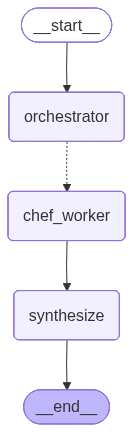

In [48]:
display(Image(orchestrater_worker.get_graph().draw_mermaid_png()))

In [66]:
# invoke the workflow with a string of meals in a dict
state = orchestrater_worker.invoke({"meals": "Steak and eggs, tacos, and chili"})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 27.76882794s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi

### Reflection Pattern

The reflection pattern is where an AI agent iteratively evaluates and imporves its own outputs through self-assessment and feedback loops, similar to reflective agents in cognitive science.

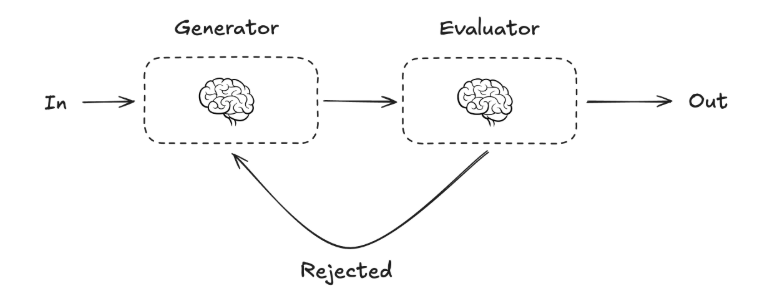

<b>State (Reflection)

In [68]:
from typing import Literal
grades = Literal[
    "ultra-conservative",
    "conservative",
    "moderate",
    "aggressive",
    "high risk"
]

class State(TypedDict):
    investment_plan: str
    investor_profile: str
    target_grade: grades
    feedback: str
    grade: grades
    n: int = 0

<b>Setup Node

Before building our Generator and Evaluator nodes, let's create a node that determines a fitting target_grade based on the investor profile.

In [69]:
grade_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an investment advisor. Given the investor’s profile and their proposed plan,"
     "choose exactly one risk classification from: ultra-conservative, conservative, moderate, aggressive, high risk."
     "Return ONLY the grade."
    ),
    ("user",
     "Investor profile:\n\n{investor_profile}\n\n"
    )
])

grade_pipe = grade_prompt | llm

In [70]:
def determine_target_grade(state: State) -> State:
    """Determines the target grade based on the investor's profile."""
    grade = grade_pipe.invoke({"investor_profile": state['investor_profile']})
    return {"target_grade": grade.content.lower()}

In [71]:
# initialize empty state except for the user inputted investor profile
dummy_state: State = {
    "investment_plan": "",
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    ),
    "target_grade": "",
    "feedback": "",
    "grade": "",
    "n": 0
}

In [72]:
import pprint
# get target grade
target_grade = determine_target_grade(dummy_state)
# update target grade with the returned dict
dummy_state.update(target_grade)
pprint(dummy_state)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 54.051654306s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

<b>Generator Node

# Phase 1 Initial Generation



In [73]:
# inital generation, no feedback, only based on profile
cathie_wood_prompt = ChatPromptTemplate.from_messages([
    ("system",
    """You are a bold, innovation-driven investment advisor inspired by Cathie Wood.

Your goal is to generate a high-conviction, forward-looking investment plan that embraces disruptive technologies,
emerging markets, and long-term growth potential. You are not afraid of short-term volatility as long as the upside is transformational.

Create an investment strategy tailored to the investor profile below. Prioritize innovation and high-reward opportunities,
such as artificial intelligence, biotechnology, blockchain, or renewable energy.

Respond with a concise investment plan in paragraph form.
"""
    ),
    ("human", "Investor profile:\n\n{investor_profile}")
])

cathie_wood_pipe = cathie_wood_prompt | llm

In [74]:
# evaluator output schema
class Feedback(BaseModel):
    grade: grades = Field(description="The risk classification of the investment plan")
    feedback: str = Field(description="A brief explanation of the evaluation and any suggestions for improvement")

<b>Phase 2: Adaptive Generation

In [75]:
ray_dalio_prompt = ChatPromptTemplate.from_messages([
    ("system",
    """You are an investment advisor inspired by Ray Dalio's principles but with adaptive strategy generation.
Your goal is to create varied, scenario-aware investment plans that respond dynamically to economic conditions,
feedback, and the investor's evolving needs. You adapt your recommendations based on previous evaluations.

CORE PRINCIPLES:
- Environmental diversification across economic regimes (growth/inflation combinations)
- Risk parity weighting by volatility, not just dollar amounts
- Inflation-aware asset selection with real return focus
- Macroeconomic scenario planning and regime identification

ADAPTATION RULES based on feedback:
- If deemed "too conservative" → Increase growth equity allocation, add emerging markets, consider alternatives
- If deemed "too aggressive" → Add defensive assets, increase bond allocation, focus on dividend stocks
- If "lacks inflation protection" → Emphasize TIPS, commodities, REITs, international exposure
- If "too complex" → Simplify to core ETF strategy with clear rationale
- If "insufficient diversification" → Add geographic, sector, or alternative asset exposure

ECONOMIC SCENARIO ADJUSTMENTS:
- Rising inflation environment → Emphasize commodities, TIPS, real estate, reduce duration
- Stagflation concerns → Focus on energy, materials, international markets, inflation hedges
- Deflationary risks → Increase government bonds, high-quality corporate bonds, cash positions
- Growth acceleration → Favor technology, consumer discretionary, small-cap growth
- Economic uncertainty → Balance with "All Weather" approach using multiple asset classes

TARGETING 15% RETURNS through:
- Strategic overweighting of growth assets during favorable conditions
- Tactical allocation adjustments based on economic regime
- Alternative investments (REITs, commodities, international) for diversification
- Leverage consideration for qualified investors
- Regular rebalancing to capture volatility

Respond with a clear, actionable investment plan that reflects current economic conditions 
and adapts to the specific feedback provided. Vary your approach significantly based on 
the grade and feedback received.
"""
    ),
    ("human",
     """Investor profile:
{investor_profile}

Previous strategy grade: {grade}

Evaluator feedback: {feedback}

Based on this feedback, create a NEW investment strategy that addresses the concerns raised 
while targeting 15% returns. Make significant adjustments from any previous approach.
""")
])

ray_dalio_pipe = ray_dalio_prompt | llm

<B>Build the Generator Node

In [76]:
def investment_plan_generator(state: State) -> dict:
    """Generates an investment plan based on the investor's profile and feedback."""
    if state.get("feedback"):
        # If feedback exists, use the Ray Dalio-inspired pipe to generate a new plan
        plan = ray_dalio_pipe.invoke({
            "investor_profile": state['investor_profile'],
            "grade": state['grade'],
            "feedback": state['feedback']
        })
    else:
        # If no feedback, use the Cathie Wood-inspired pipe for initial plan generation
        plan = cathie_wood_pipe.invoke({
            "investor_profile": state['investor_profile']
        })
    return {"investment_plan": plan.content}

In [77]:
initial_plan = investment_plan_generator(dummy_state)

dummy_state.update(initial_plan)
pprint(dummy_state)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 53.54717535s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi

<b>Evaluator Node

The Evaluator node is responsible for critically accessing the investment strategy generated by the system.

In [78]:
# Warren Buffet style evaluation prompt
evaluator_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """You are an investment risk evaluator inspired by Warren Buffett's value investing philosophy.

Your task is to assess whether a proposed investment strategy aligns with conservative, value-driven principles 
that emphasize capital preservation, long-term stability, and sound business fundamentals. You should be 
skeptical of speculative investments, high-volatility assets, and short-term market trends.

RISK CLASSIFICATION LEVELS:
- ultra-conservative: Extremely safe, minimal risk of loss
- conservative: Low risk, prioritizes capital preservation  
- moderate: Balanced approach with acceptable risk-reward ratio
- aggressive: Higher risk for potentially greater returns
- high risk: Speculative investments with significant loss potential

EVALUATION CRITERIA:
- Business clarity: Is the investment easily understandable with transparent cash flows?
- Margin of safety: Does the investment price provide protection against downside risk?
- Capital preservation: Will this strategy protect wealth over the long term?
- Investor alignment: Does this match a conservative investor's risk tolerance and goals?
- Quality fundamentals: Are the underlying assets financially sound with competitive advantages?

Return your assessment in the following  format:
{{
  "grade": "<investment risk level>",
  "feedback": "<concise explanation of the assigned risk level and key reasoning>"
}}
"""
    ),
    ("human", 
     "Evaluate this investment plan:\n\n{investment_plan}\n\nFor this investor profile:\n\n{investor_profile}\n\nAnd provide feedback that matches this target risk level: {target_grade}")
])

# create the pipe with the structured output that outputs a Feedback object
buffett_evaluator_pipe = evaluator_prompt | llm.with_structured_output(Feedback)

<b>Build the generator Node

In [81]:
def evaluate_plan(state: State) -> State:
    """Evaluates the investment plan against the target grade and provides feedback."""
    evaluation = buffett_evaluator_pipe.invoke({
        "investment_plan": state['investment_plan'],
        "investor_profile": state['investor_profile'],
        "target_grade": state['target_grade']
    })
    return {"grade": evaluation.grade, "feedback": evaluation.feedback, "n": state['n'] + 1}

In [82]:
evaluated_feedback = evaluate_plan(dummy_state)
# update the dummy state with the feedback
dummy_state.update(evaluated_feedback)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 24.701459559s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
print(f"Grade: {dummy_state["grade"]}")
print(f"Feedback: {dummy_state["feedback"]}")

<b>Routing Node

In [84]:
def route_investment(state: State, iteration_limit: int = 3) -> State:
    """Route investment based on risk grade evaluation"""
    # get grades
    current_grade = state.get("grade", "MISSING")
    target_grade = state.get("target_grade", "MISSING")
    # check if grades match
    match = current_grade == target_grade

    # print out the tracked values
    print(f"=== ROUTING  ===")
    print(f"Current grade: '{current_grade}'")
    print(f"Target risk profile: '{target_grade}'")
    print(f"Match: {match}")
    print(f"Number of trials: {state['n']}")

    # routing logic
    if match: # grades match
        print("→ Routing to: Accepted")
        return "Accepted"
    elif state['n'] > iteration_limit: # review iterations exceeds limit
        print("→ Too many iterations, stopping")
        return "Accepted"
    else: # grades don't match
        print("→ Routing to: Rejected + Feedback")
        return "Rejected + Feedback"

<b>Building the Workflow (Reflection)

In [85]:
# initialize StateGraph with the given State schema
optimizer_builder = StateGraph(State)

# add the setup, generator, and evaluator nodes
optimizer_builder.add_node("determine_target_grade", determine_target_grade)
optimizer_builder.add_node("investment_plan_generator", investment_plan_generator)
optimizer_builder.add_node("evaluate_plan", evaluate_plan)

# define the flow with edges
optimizer_builder.add_edge(START, "determine_target_grade")
optimizer_builder.add_edge("determine_target_grade", "investment_plan_generator")
optimizer_builder.add_edge("investment_plan_generator", "evaluate_plan")

In [86]:
# add conditional edge for reflection
optimizer_builder.add_conditional_edges(
    "evaluate_plan",
    lambda state: route_investment(state),
    {
        "Accepted": END,
        "Rejected + Feedback": "investment_plan_generator",
    },
)

In [87]:
# compile the workflow
optimizer_workflow = optimizer_builder.compile()

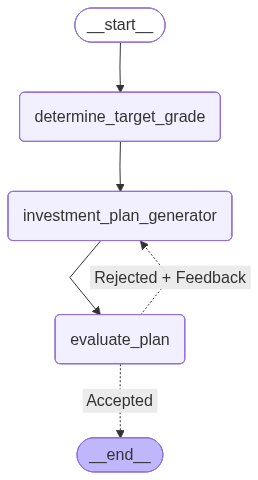

In [88]:
# display the graph
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [ ]:
# invoke the workflow with an example investor profile
state = optimizer_workflow.invoke({
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    )
})

In [ ]:
def pretty_print_final_state(state: dict):
    print("🎯 Final Investment Plan Summary\n" + "="*40)
    print(f"\n📌 Investor Profile:\n{state['investor_profile']}")
    
    print("\n📈 Target Risk Grade:", state['target_grade'])
    print("📊 Final Assigned Grade:", state['grade'])
    print("🔁 Iterations Taken:", state['n'])

    print("\n📝 Evaluator Feedback:\n" + "-"*30)
    print(state['feedback'])

    print("\n📃 Final Investment Plan:\n" + "-"*30)
    print(state['investment_plan'])

pretty_print_final_state(state)